In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [2]:
df = pd.read_csv('../Model/Backup/historico_otimizacao.csv').sort_values(by='iou_wu', ascending=False)
df

,trial,timestamp,model_id,status,iou_wu,faultCount_max,faultCount_min,faultCurveMax,faultCurveProb,faultDecaySigma_max,...,noiseLevel_max,noiseLevel_min,shearGradient_max,shearGradient_min,shearOffset_max,shearOffset_min,waveletDt,waveletDuration,waveletFreq_max,waveletFreq_min
111,241,2026-06-24T16:13:14.616222,model_113,COMPLETE,0.719151,10,5,8.699330,0.012886,52,...,0.607074,0.018009,0.014489,-0.097963,3.170065,-8.603805,0.001210,0.102722,105,61
122,252,2026-06-25T17:28:34.112298,model_124,COMPLETE,0.718628,12,5,9.444201,0.005430,52,...,0.624594,0.027870,0.007087,-0.092067,4.059965,-8.806837,0.001539,0.098151,105,62
117,247,2026-06-25T05:15:55.305707,model_119,COMPLETE,0.714958,8,4,9.217900,0.018816,47,...,0.635021,0.017019,0.011601,-0.091948,3.661423,-7.915287,0.001090,0.101225,105,62
112,242,2026-06-24T18:22:34.548296,model_114,COMPLETE,0.701087,10,4,7.024448,0.008166,68,...,0.609075,0.010968,0.027474,-0.091727,3.104085,-8.459166,0.001009,0.109087,98,81
127,257,2026-06-26T04:23:34.501449,model_129,COMPLETE,0.700971,12,5,8.724747,0.010011,52,...,0.627625,0.024860,0.019708,-0.092978,3.488749,-9.104578,0.001360,0.101678,101,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8,10,2026-06-11T20:22:07.992178,model_10,COMPLETE,0.216417,4,3,1.037522,0.687425,87,...,0.677664,0.019269,0.031305,-0.147456,0.909922,-7.222081,0.003597,0.078805,252,115
3,4,2026-06-11T04:35:18.810433,model_5,COMPLETE,0.199859,10,1,2.510694,0.675591,125,...,0.376741,0.030478,0.068162,-0.052757,3.703308,-9.492713,0.000666,0.057029,161,72
0,1,2026-06-10T18:28:11.538217,model_2,COMPLETE,0.192165,9,4,4.645269,0.080193,64,...,0.247999,0.040420,0.020861,-0.166987,1.863687,-9.664270,0.004845,0.143355,97,41
5,7,2026-06-11T11:22:09.037501,model_7,COMPLETE,0.151409,15,2,6.106820,0.300314,156,...,0.420540,0.034801,0.049865,-0.195623,2.605793,-4.053027,0.004713,0.092384,125,55


In [3]:
df.loc[df.status == 'FAIL']

,trial,timestamp,model_id,status,iou_wu,faultCount_max,faultCount_min,faultCurveMax,faultCurveProb,faultDecaySigma_max,...,noiseLevel_max,noiseLevel_min,shearGradient_max,shearGradient_min,shearOffset_max,shearOffset_min,waveletDt,waveletDuration,waveletFreq_max,waveletFreq_min


# ANÁLISE DOS DADOS (SCATTER PLOT)

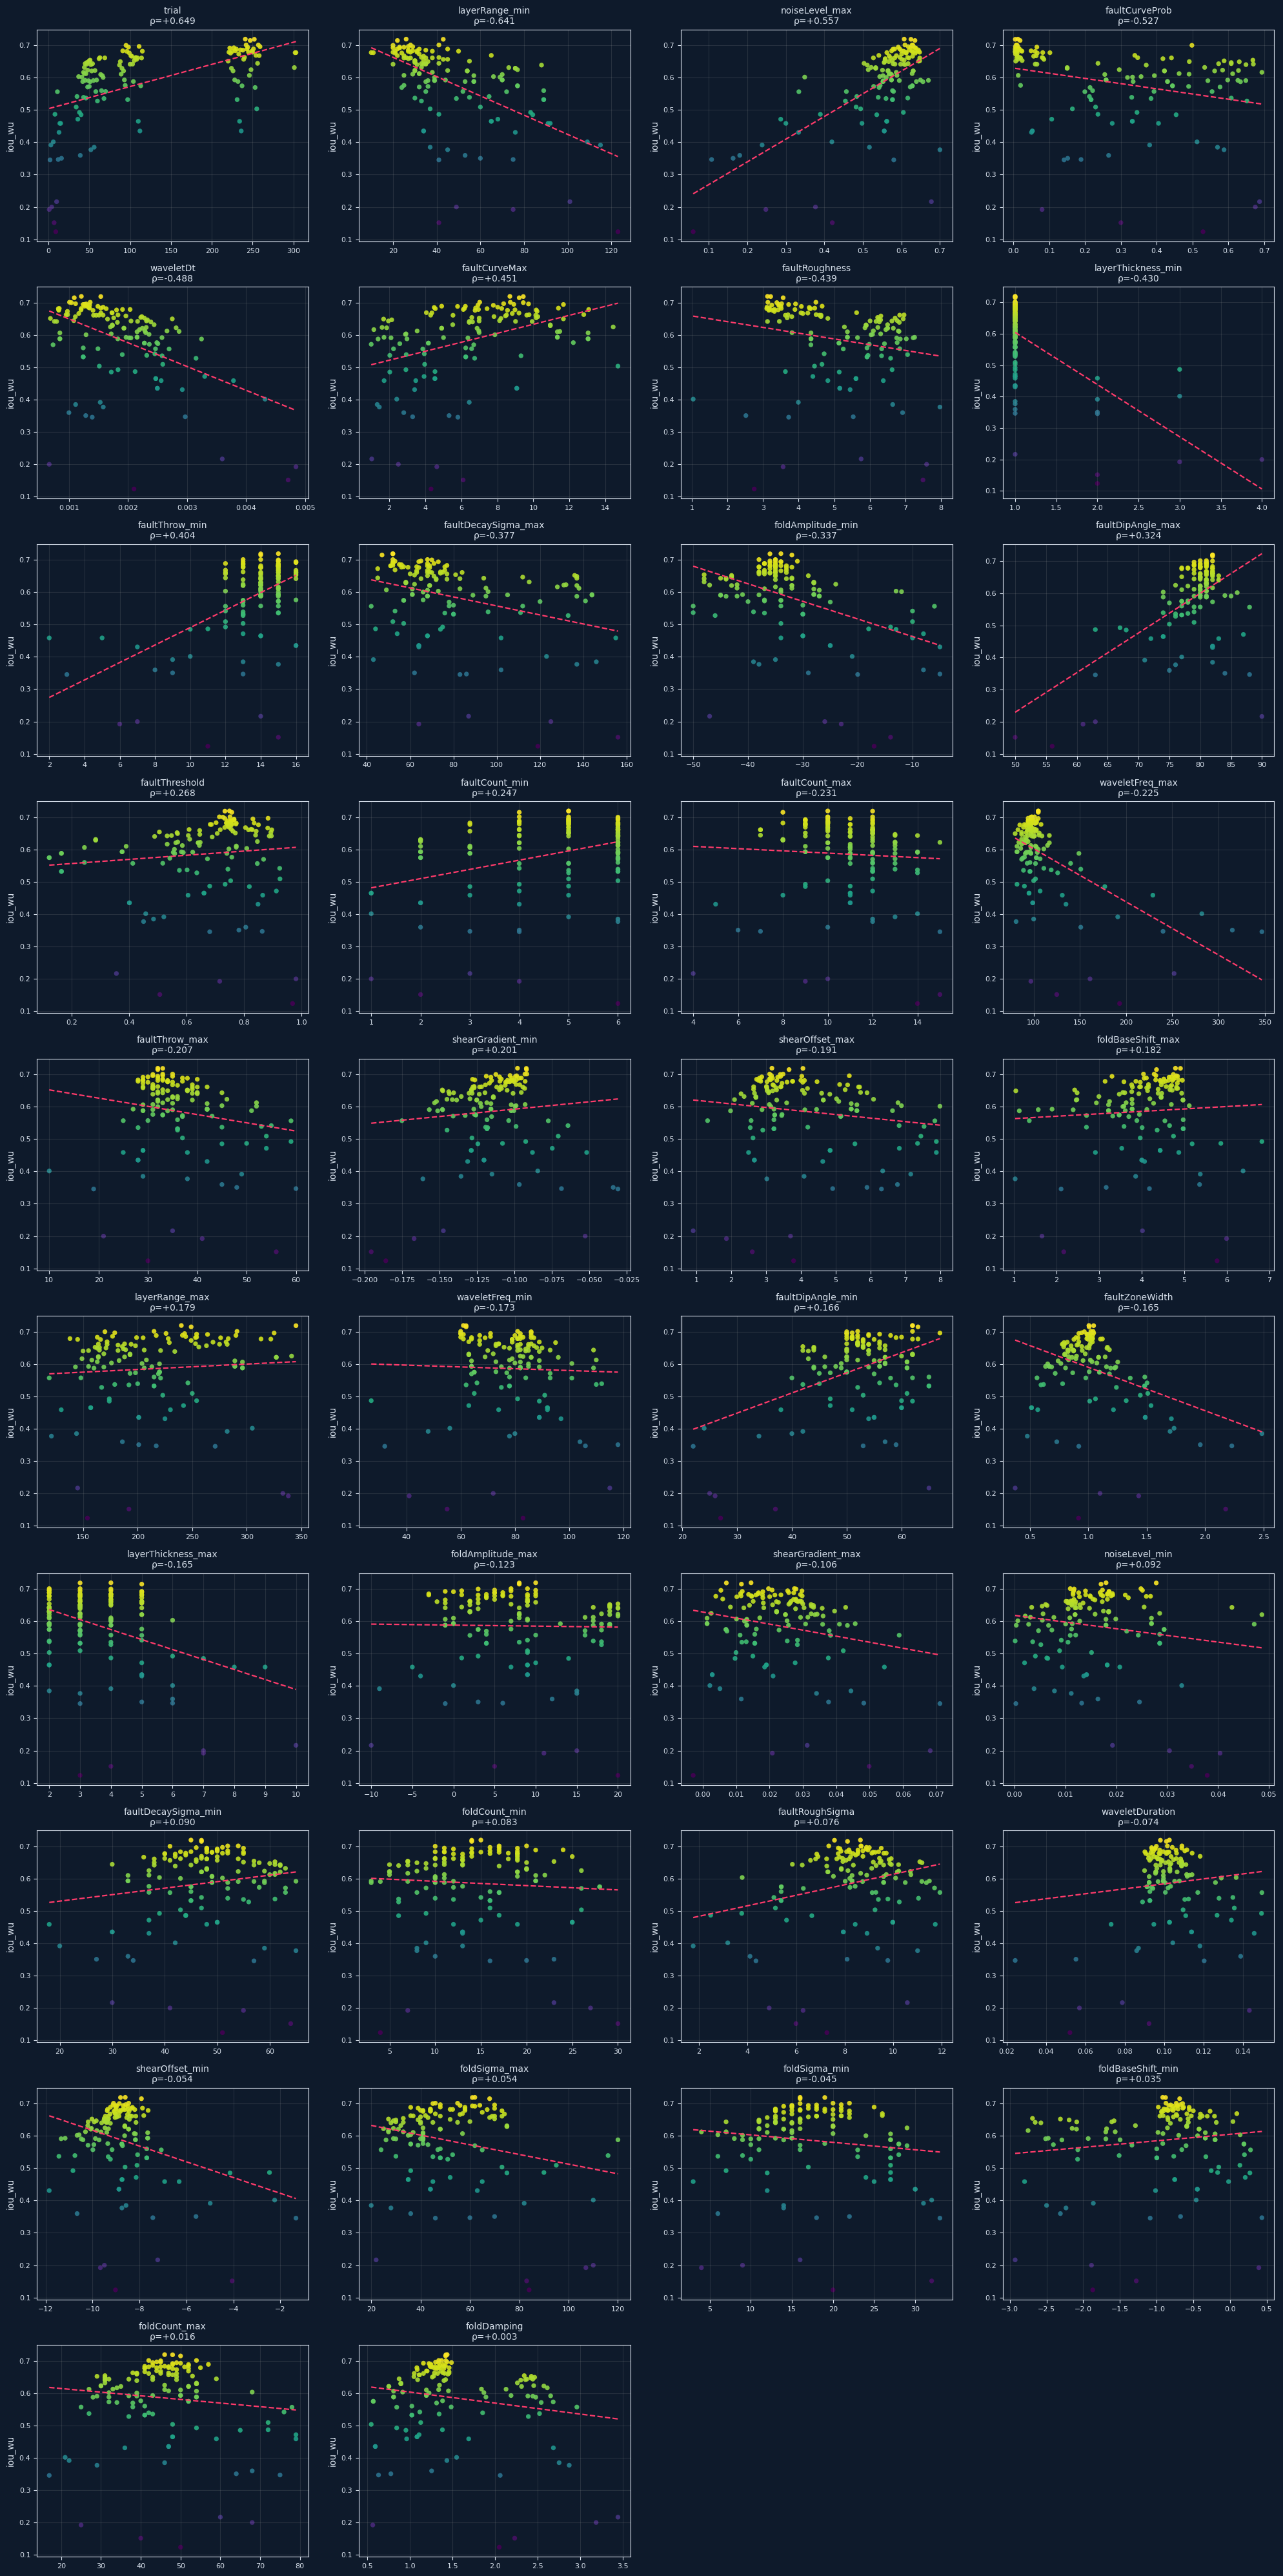

In [4]:
class CrossCorrelation:
    def __init__(self, df, maxCols=4, cmap='viridis', dark=True):
        self.numeric = df.select_dtypes(include=[np.number])
        self.corr = self.numeric.corr(method='spearman')
        self.maxCols = maxCols
        self.cmap = cmap
        self.dark = dark

    def top(self, var, max=5):
        s = self.corr[var].drop(labels=[var]).dropna()
        s = s.reindex(s.abs().sort_values(ascending=False).index)
        return list(s.index[:max])

    def plot(self, var, max=5):
        partners = self.top(var, max)
        bg = '#0e1a2b' if self.dark else 'white'
        fg = '#d8e1ec' if self.dark else 'black'
        count = len(partners)
        numCols = self.maxCols if count >= self.maxCols else count
        numRows = math.ceil(count / numCols)
        fig = plt.figure(figsize=(5 * numCols, 4 * numRows))
        fig.patch.set_facecolor(bg)
        for i, other in enumerate(partners):
            x = self.numeric[other]
            y = self.numeric[var]
            mask = x.notna() & y.notna()
            xv, yv = x[mask], y[mask]
            ax = plt.subplot(numRows, numCols, i + 1)
            ax.set_facecolor(bg)
            ax.scatter(xv, yv, c=yv, cmap=self.cmap, s=28, edgecolors='none', alpha=0.9)
            coef = np.polyfit(xv, yv, 1)
            line = np.linspace(xv.min(), xv.max(), 100)
            ax.plot(line, np.polyval(coef, line), '--', color='#ff3b6b', linewidth=1.6)
            ax.set_title(f"{other}\n\u03c1={self.corr.loc[var, other]:+.3f}", color=fg, fontsize=10)
            ax.set_ylabel(var, color=fg)
            ax.tick_params(colors=fg, labelsize=8)
            for s in ax.spines.values():
                s.set_color(fg)
            ax.grid(True, alpha=0.15)
        plt.tight_layout()
        plt.show()
        plt.close(fig)


CrossCorrelation(df).plot('iou_wu', max=None)

# ANÁLISE DOS DADOS (CORRELAÇÕES)

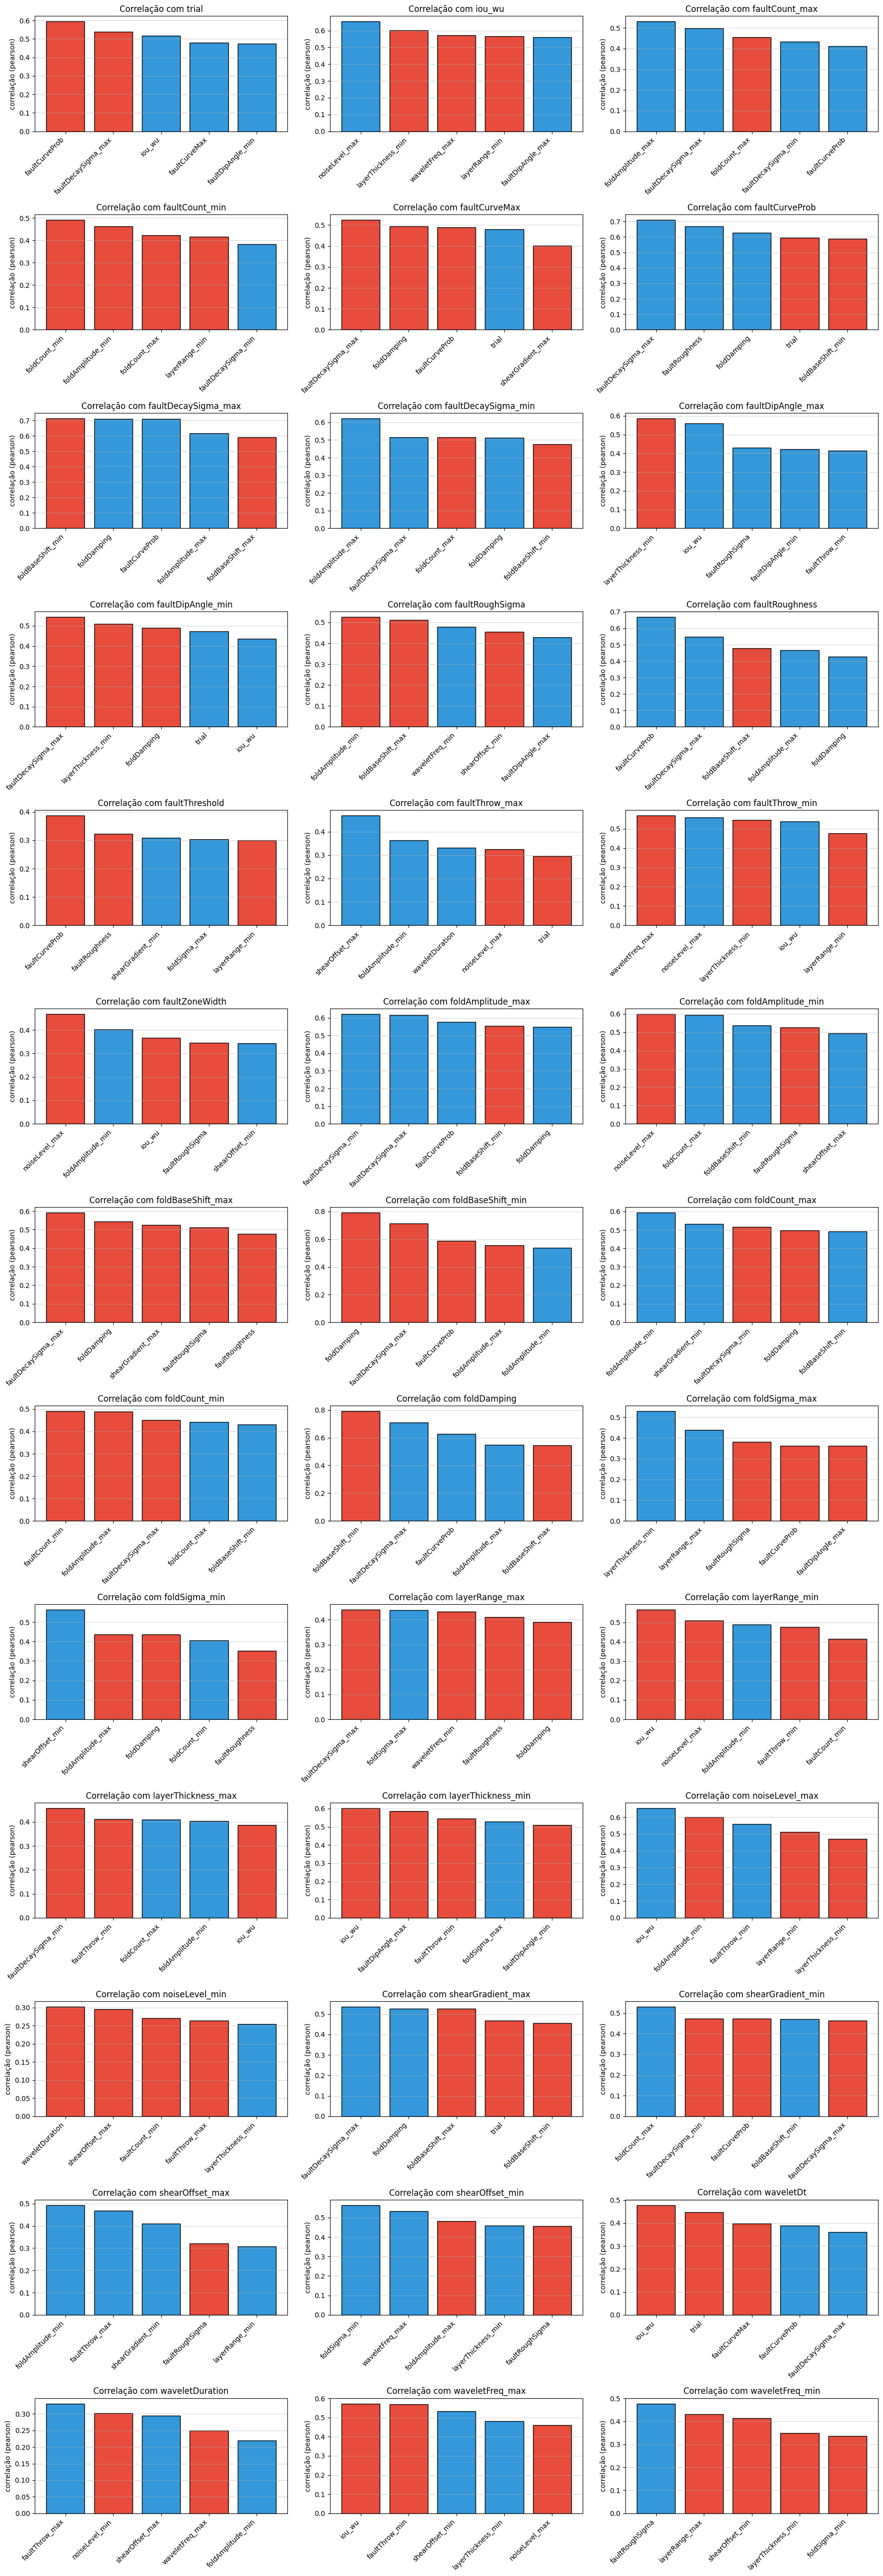

In [5]:
class Correlations:
    def __init__(self, df, tresh=0.5, method='pearson', max_cols=3):
        self.df = df.select_dtypes(include='number').copy()
        self.tresh  = tresh
        self.method = method
        self.max_cols = max_cols
        self.matrix   = self.df.corr(method=self.method)

    def get(self, target_col):
        if target_col not in self.matrix.columns:
            return {}
        corr = self.matrix[target_col].drop(target_col)
        keep = corr[abs(corr) >= self.tresh].sort_values(key=abs, ascending=False)
        return {ref: v for ref, v in keep.items()}
    
    def all(self):
        result = {}
        for col in self.matrix.columns:
            info = self.get(col)
            if info:
                result[col] = info
        return result

    def bars(self, ax, target_col, show_max=None):
        corrs = self.get(target_col)
        if not corrs:
            return
        refs = list(corrs.keys())[:show_max]
        labels = [str(r)[:20] for r in refs]
        values = [abs(corrs[r]) for r in refs]
        colors = ['#3498db' if corrs[r] > 0 else '#e74c3c' for r in refs]
        ax.bar(range(len(values)), values, color=colors, edgecolor='black')
        ax.set_title(f'Correlação com {target_col}')
        ax.set_ylabel(f'correlação ({self.method})')
        ax.grid(axis='y', alpha=0.5)
        ax.set_xticks(range(len(labels)))
        if len(labels) >= 4:
            ax.set_xticklabels(labels, rotation=45, ha='right')
        else:
            ax.set_xticklabels(labels)

    def plot(self, target_col, show_max=None):
        fig, ax = plt.subplots(figsize=(8, 5))
        self.bars(ax, target_col, show_max)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

    def plot_all(self, targets=None, show_max=None):
        targets = targets if targets is not None else list(self.all().keys())
        count   = len(targets)
        num_cols = self.max_cols if count >= self.max_cols else count
        num_rows = math.ceil(count / num_cols)
        fig = plt.figure(figsize=(6 * num_cols, 4 * num_rows))
        for i, target_col in enumerate(targets):
            ax = plt.subplot(num_rows, num_cols, i + 1)
            self.bars(ax, target_col, show_max)
        plt.tight_layout()

    def heatmap(self, target_col, n=None):
        if target_col not in self.matrix.columns:
            return
        top_cols = self.matrix[target_col].abs().sort_values(ascending=False).drop(target_col)
        if n:
            top_cols = top_cols.head(n)
        cols_to_plot = [target_col] + top_cols.index.tolist()
        matrix_subset = self.matrix.loc[cols_to_plot, cols_to_plot]
        plt.figure(figsize=(17, 10))
        sns.heatmap(matrix_subset.abs(), annot=True, fmt=".2f", cmap='Blues', vmin=0, vmax=1)
        plt.title(f'Mapa de Calor (Top {n})')
        plt.xticks(rotation=45, ha='right')


Correlations(df, tresh=0.0, max_cols=3).plot_all(show_max=5)